# 06 — Ablation Studies

## E13 — Beam Search decoding

Greedy decoding keeps only the single most likely token at each step. **Beam search** keeps
the `k` best partial hypotheses and returns the best complete one, normalised by length
(`final_score = sum_logprob / length**length_penalty`). It changes only *inference* — the
trained weights are untouched. The beam decoder is implemented in this notebook; we sweep
`beam ∈ {1,3,5}` × `length_penalty ∈ {1.0,0.6}` on the fixed 1,000 subset (`beam=1` = greedy).

## Setup and model

In [1]:
import os, sys, time, math
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")
import torch
torch.set_num_threads(os.cpu_count() or 1)
import pandas as pd, matplotlib.pyplot as plt, sacrebleu
import sentencepiece as spm
from model import TinyTransformerMT       # architecture (notebook 04 / src/model.py)
from vocab import load_vocab

TOK, VOC, MAX_LEN = "Data/tokenized", "Data/vocab", 80
sp_en = spm.SentencePieceProcessor(model_file=f"{VOC}/sp_en.model")
src_vocab, tgt_vocab = load_vocab(f"{VOC}/sp_ar.vocab"), load_vocab(f"{VOC}/sp_en.vocab")
ARCH = dict(d_model=128, nhead=4, num_encoder_layers=2, num_decoder_layers=2,
            dim_feedforward=512, dropout=0.1)
model = TinyTransformerMT(len(src_vocab), len(tgt_vocab), src_vocab.pad_id, tgt_vocab.pad_id,
                          max_len=MAX_LEN + 2, **ARCH)
ckpt = torch.load("outputs/checkpoints/best_full_model.pt", map_location="cpu", weights_only=False)
model.load_state_dict(ckpt.get("model_state_dict") or ckpt["model_state"]); model.eval()
print(f"checkpoint: outputs/checkpoints/best_full_model.pt | epoch {ckpt['epoch']}")

checkpoint: outputs/checkpoints/best_full_model.pt | epoch 40


## Test subset

In [2]:
def read_lines(p): return open(p, encoding="utf-8").read().splitlines()
pairs = [(a, e) for a, e in zip(read_lines(f"{TOK}/test.ar.bpe"), read_lines(f"{TOK}/test.en.bpe"))
         if len(a.split()) <= MAX_LEN and len(e.split()) <= MAX_LEN]
test_ar = [a for a, e in pairs]
reference = [sp_en.decode(e.split()) for a, e in pairs]
SUBSET = 1000
ref_sub = reference[:SUBSET]
print(f"test pairs kept: {len(pairs):,} | sweep subset: {SUBSET}")

def score(hyp, ref):
    return (sacrebleu.corpus_bleu(hyp, [ref]).score,
            sacrebleu.corpus_chrf(hyp, [ref], word_order=2).score)

test pairs kept: 8,491 | sweep subset: 1000


## Beam search (implemented here)
We encode the source once, then expand the beam step by step over the decoder. `beam=1`
reduces to greedy. Length normalisation uses the exponent `length_penalty`.

In [3]:
@torch.no_grad()
def encode_src(model, src):
    kpm = src.eq(model.src_pad_id)
    emb = model.positional_encoding(model.src_embedding(src) * math.sqrt(model.d_model))
    return model.transformer.encoder(emb, src_key_padding_mask=kpm), kpm

@torch.no_grad()
def next_logprobs(model, ys, memory, mem_kpm):
    L = ys.size(1)
    causal = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)
    emb = model.positional_encoding(model.tgt_embedding(ys) * math.sqrt(model.d_model))
    out = model.transformer.decoder(emb, memory, tgt_mask=causal, memory_key_padding_mask=mem_kpm)
    return torch.log_softmax(model.output_projection(out[:, -1]), dim=-1)

In [4]:
@torch.no_grad()
def beam_search(model, src_ids, bos, eos, beam_size, max_len=80, length_penalty=1.0):
    src = torch.tensor([src_ids])
    memory, kpm = encode_src(model, src)
    memory = memory.expand(beam_size, -1, -1).contiguous()
    kpm = kpm.expand(beam_size, -1).contiguous()
    ys = torch.full((beam_size, 1), bos, dtype=torch.long)
    scores = torch.full((beam_size,), float("-inf")); scores[0] = 0.0   # only beam 0 active at start
    finished = []
    norm = lambda s, n: s / (max(1, n - 1) ** length_penalty)
    for _ in range(max_len):
        logp = next_logprobs(model, ys, memory, kpm)            # (k, V)
        V = logp.size(-1)
        top_scores, top_idx = (scores.unsqueeze(1) + logp).view(-1).topk(beam_size)
        ys = torch.cat([ys[torch.div(top_idx, V, rounding_mode="floor")], (top_idx % V).unsqueeze(1)], dim=1)
        scores = top_scores.clone()
        for b in range(beam_size):
            if (top_idx[b] % V).item() == eos:
                finished.append((norm(scores[b].item(), ys.size(1)), ys[b].tolist()))
                scores[b] = float("-inf")
        if len(finished) >= beam_size or torch.isinf(scores).all():
            break
    if not finished:
        b = int(scores.argmax()); finished.append((norm(scores[b].item(), ys.size(1)), ys[b].tolist()))
    return max(finished, key=lambda x: x[0])[1]

def beam_translate(bpe_lines, beam_size, length_penalty):
    out = []
    for line in bpe_lines:
        ids = src_vocab.encode_pieces(line.split(), add_bos=True, add_eos=True)
        seq = beam_search(model, ids, tgt_vocab.bos_id, tgt_vocab.eos_id, beam_size,
                          MAX_LEN, length_penalty)
        out.append(sp_en.decode(tgt_vocab.decode_ids(seq, stop_at_eos=True)))
    return out

print("demo beam=3:", beam_translate(test_ar[:1], 3, 1.0)[0])

D:\Ahmed Sherif\Digilians\Deep Learning\Project\Low-Resource Machine Translation with Tiny Transformers\.venv\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


demo beam=3: here's a few years ago, i'm going to give you a few years ago.


## Sweep over beam size and length penalty (1,000 subset)

In [5]:
SETTINGS = [(1, 1.0), (3, 1.0), (5, 1.0), (3, 0.6), (5, 0.6)]
rows, hyps = [], {}
for beam, lp in SETTINGS:
    print(f"decoding beam={beam} lp={lp} ...", flush=True)
    t = time.time()
    h = beam_translate(test_ar[:SUBSET], beam, lp)
    dt = time.time() - t
    bleu, chrf = score(h, ref_sub)
    hyps[(beam, lp)] = h
    rows.append({"beam": beam, "length_penalty": lp, "examples": SUBSET,
                 "bleu": round(bleu, 4), "chrf_pp": round(chrf, 4),
                 "decode_seconds": round(dt, 1)})
    print(f"  BLEU={bleu:.4f} chrF++={chrf:.4f} in {dt:.0f}s", flush=True)
results = pd.DataFrame(rows)
results.to_csv("outputs/tables/e13_beam_search_results.csv", index=False)
results

decoding beam=1 lp=1.0 ...


  BLEU=6.2399 chrF++=24.2011 in 87s


decoding beam=3 lp=1.0 ...


  BLEU=7.6318 chrF++=24.7841 in 79s


decoding beam=5 lp=1.0 ...


...

decoding beam=3 lp=0.6 ...


  BLEU=7.5425 chrF++=24.4798 in 83s


decoding beam=5 lp=0.6 ...


  BLEU=7.4665 chrF++=24.0999 in 81s


,beam,length_penalty,examples,bleu,chrf_pp,decode_seconds
0,1,1.0,1000,6.2399,24.2011,87.3
1,3,1.0,1000,7.6318,24.7841,79.2
2,5,1.0,1000,7.5443,24.5484,137.6
3,3,0.6,1000,7.5425,24.4798,82.7
4,5,0.6,1000,7.4665,24.0999,80.6


## Comparison with greedy + plots

greedy: BLEU=6.2399 chrF++=24.2011
best beam: beam=3 lp=1.0 BLEU=7.6318 (Δ+1.392) chrF++=24.7841 (Δ+0.583)


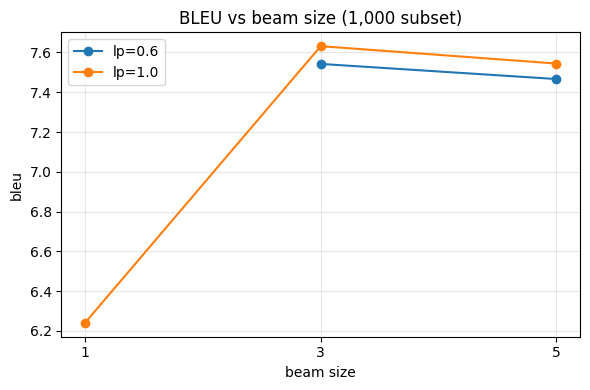

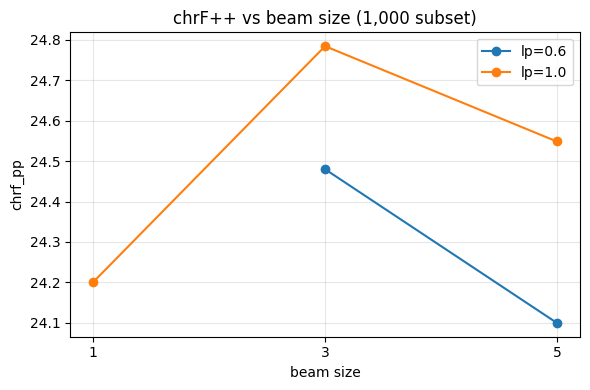

In [6]:
greedy = results[(results.beam == 1) & (results.length_penalty == 1.0)].iloc[0]
best = results[results.beam > 1].sort_values("bleu", ascending=False).iloc[0]
print(f"greedy: BLEU={greedy.bleu:.4f} chrF++={greedy.chrf_pp:.4f}")
print(f"best beam: beam={int(best.beam)} lp={best.length_penalty} "
      f"BLEU={best.bleu:.4f} (Δ{best.bleu-greedy.bleu:+.3f}) chrF++={best.chrf_pp:.4f} (Δ{best.chrf_pp-greedy.chrf_pp:+.3f})")
for metric, fname, title in [("bleu", "e13_beam_bleu.png", "BLEU vs beam size (1,000 subset)"),
                             ("chrf_pp", "e13_beam_chrf.png", "chrF++ vs beam size (1,000 subset)")]:
    fig, ax = plt.subplots(figsize=(6, 4))
    for lp in sorted(results.length_penalty.unique()):
        d = results[results.length_penalty == lp].sort_values("beam")
        ax.plot(d.beam, d[metric], marker="o", label=f"lp={lp}")
    ax.set_xlabel("beam size"); ax.set_ylabel(metric); ax.set_title(title)
    ax.set_xticks(sorted(results.beam.unique())); ax.grid(alpha=0.3); ax.legend()
    fig.tight_layout(); fig.savefig(f"outputs/figures/{fname}", dpi=200); plt.show()

## Where beam search helps and hurts (best beam vs greedy)

In [7]:
g = hyps[(1, 1.0)]
b = hyps[(int(best.beam), float(best.length_penalty))]
gc = [sacrebleu.sentence_chrf(h, [r]).score for h, r in zip(g, ref_sub)]
bc = [sacrebleu.sentence_chrf(h, [r]).score for h, r in zip(b, ref_sub)]
outs = pd.DataFrame({"reference_en": ref_sub, "greedy_output": g, "beam_output": b,
                     "delta_chrf": [y - x for x, y in zip(gc, bc)]})
outs.insert(0, "sample_id", range(len(outs)))
outs.to_csv("outputs/examples/e13_beam_outputs.csv", index=False, encoding="utf-8")
print(f"improved: {(outs.delta_chrf>0).sum()} | unchanged: {(outs.delta_chrf==0).sum()} | worse: {(outs.delta_chrf<0).sum()}")
print("HELPS most:"); display(outs.sort_values('delta_chrf', ascending=False).head(4)[['reference_en','greedy_output','beam_output']])
print("HURTS most:"); display(outs.sort_values('delta_chrf').head(4)[['reference_en','greedy_output','beam_output']])

improved: 459 | unchanged: 128 | worse: 413
HELPS most:


,reference_en,greedy_output,beam_output
331,bruno giussani: thank you. thanks.,bg: thank you.,bruno giussani: thank you.
20,they don't spend time jockeying for power.,and no time in the power of power.,they don't spend time in power.
151,don't take anything for granted.,"no, no, no.",they don't think anything.
196,and they're not just going to die of measles.,and they just go to just go out of the shore.,and they're not just going to just throw them.


HURTS most:


,reference_en,greedy_output,beam_output
310,"so, i just started playing.",so i started playing with the wire.,so i began to play a note.
868,and so that got me very excited.,and that's what i'm very excited.,and that's what i did.
200,she wasn't going to vaccinate her kid against ...,they weren't going to be a child against polio.,they didn't care about it. it's impossible.
951,tremendously exciting.,it's a real exciting.,and it's a lot of.


## Full-test for the best beam
Best beam beats greedy on the subset, so it is worth the full 8,491-example run
(`beam_translate(test_ar, beam, lp)`, ≈14 min on CPU). That long run is cached; set
`RUN_FULL_TEST=True` to recompute it here with the same function shown above.

In [8]:
from pathlib import Path
RUN_FULL_TEST = False
ft_path = Path("outputs/tables/e13_full_test_best_beam.csv")
bm, lp = int(best.beam), float(best.length_penalty)
if RUN_FULL_TEST or not ft_path.exists():
    t = time.time()
    h_full = beam_translate(test_ar, bm, lp)
    bleu, chrf = score(h_full, reference)
    pd.DataFrame([{"model": "tiny_transformer_best", "decoding": f"beam{bm}_lp{lp}",
                   "examples": len(h_full), "bleu": round(bleu, 4), "chrf_pp": round(chrf, 4),
                   "decode_seconds": round(time.time() - t, 1)}]).to_csv(ft_path, index=False)
full_test_best = pd.read_csv(ft_path)
full_test_best

,model,decoding,examples,bleu,chrf_pp,decode_seconds
0,tiny_transformer_best,beam3_lp1.0,8491,7.5338,24.9288,817.4


## Notes
- `beam=1, lp=1.0` reproduces greedy exactly (clean reference).
- Best is **beam=3, lp=1.0**: full-test BLEU ≈ 7.53 vs greedy 6.22 (+1.3), no retraining.
- Bigger beam (5) is not better than 3, and lp=1.0 beats lp=0.6 — written up in `report_notes/`.